# EcoLens: Analysing Global Plastic Pollution by Corporate Accountability
**Group Name:** EcoLens  
**Members:** Jagan Nagappan, Kota Sundar Koushik, Lee Chang Hong, Nguyen Thi Minh Xuan, Panchetty Shreya , Xiao Man  
**Dataset:** Break Free From Plastic — Plastic Pollution Audit Data (2019–2020)

<p>To identify and analyze 'Local Giants'—parent companies that rank as a top plastic polluter within a specific country (Top 3) but remain 'invisible' in global Top 10 rankings. This study aims to uncover localized plastic economies and domestic brands that contribute significantly to environmental waste but are often overlooked by global corporate accountability audits.</p>


Introduction


Paragraph 1

Paragraph 2

#Data Cleaning and Summary

In [1]:
pip install pycountry_convert


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Users/XuanNguyen/Documents/NUS/DSS5201/dss5201-visualization/src/venv-dss5201/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# --- Setup & Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re

In [3]:
# Load data from local file
import os
data_path = os.path.join("data", "plastics.csv")

In [4]:
#Load and inspect
df = pd.read_csv("../data/plastics.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (13380, 14)


,country,year,parent_company,empty,hdpe,ldpe,o,pet,pp,ps,pvc,grand_total,num_events,volunteers
0,Argentina,2019,Grand Total,0.0,215.0,55.0,607.0,1376.0,281.0,116.0,18.0,2668.0,4,243.0
1,Argentina,2019,Unbranded,0.0,155.0,50.0,532.0,848.0,122.0,114.0,17.0,1838.0,4,243.0
2,Argentina,2019,The Coca-Cola Company,0.0,0.0,0.0,0.0,222.0,35.0,0.0,0.0,257.0,4,243.0
3,Argentina,2019,Secco,0.0,0.0,0.0,0.0,39.0,4.0,0.0,0.0,43.0,4,243.0
4,Argentina,2019,Doble Cola,0.0,0.0,0.0,0.0,38.0,0.0,0.0,0.0,38.0,4,243.0


In [5]:
print("=== df.info() ===")
df.info()
print()
print("=== df.describe() ===")
df.describe(include='all')

=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 13380 entries, 0 to 13379
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         13380 non-null  str    
 1   year            13380 non-null  int64  
 2   parent_company  13329 non-null  str    
 3   empty           10137 non-null  float64
 4   hdpe            11734 non-null  float64
 5   ldpe            11303 non-null  float64
 6   o               13113 non-null  float64
 7   pet             13166 non-null  float64
 8   pp              11884 non-null  float64
 9   ps              11408 non-null  float64
 10  pvc             9052 non-null   float64
 11  grand_total     13366 non-null  float64
 12  num_events      13380 non-null  int64  
 13  volunteers      13273 non-null  float64
dtypes: float64(10), int64(2), str(2)
memory usage: 1.4 MB

=== df.describe() ===


,country,year,parent_company,empty,hdpe,ldpe,o,pet,pp,ps,pvc,grand_total,num_events,volunteers
count,13380,13380.000000,13329,10137.000000,11734.000000,11303.000000,13113.000000,13166.000000,11884.000000,11408.000000,9052.000000,13366.00000,13380.000000,13273.000000
unique,69,NaN,10821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,EMPTY,NaN,The Coca-Cola Company,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1346,NaN,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2019.305232,NaN,0.411759,3.046020,10.319384,49.613590,20.940301,8.220801,1.862114,0.350088,90.15083,33.369806,1117.645295
std,NaN,0.460523,NaN,22.586066,66.123044,194.644067,1601.989534,428.157766,141.805081,39.737064,7.894296,1873.68134,44.708642,1812.402748
min,NaN,2019.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000
25%,NaN,2019.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,4.000000,114.000000
50%,NaN,2019.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,15.000000,400.000000
75%,NaN,2020.000000,NaN,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.00000,42.000000,1416.000000


In [6]:
# 1. Remove aggregate / non-company rows
df = df[(df['parent_company'] != 'Grand Total') & (df['parent_company'] != 'Unbranded') & (df['parent_company'] != '#ERROR!')]

# 2. Remove rows where parent_company is numeric
df = df[~df['parent_company'].str.match(r'^[\d\s\-\/\.\,]+$', na=False)]

# 3. Drop rows with missing parent_company
df = df.dropna(subset=['parent_company'])

# 4. Standardise country names
df['country'] = df['country'].str.strip().str.title()
country_remap = {
    'Cote D_Ivoire'                                     : "Cote d'Ivoire",
    'Taiwan_ Republic Of China (Roc)'                   : 'Taiwan',
    'United Kingdom Of Great Britain & Northern Ireland': 'United Kingdom',
    'Empty'                                             : None,   # drop
}
df['country'] = df['country'].replace(country_remap)
df = df.dropna(subset=['country'])

# 5. Fill NaN plastic-type columns with 0
plastic_cols = ['empty', 'hdpe', 'ldpe', 'o', 'pet', 'pp', 'ps', 'pvc']
df[plastic_cols] = df[plastic_cols].fillna(0)
df['grand_total'] = df['grand_total'].fillna(0)

# 6. Remove zero-count entries
df = df[df['grand_total'] > 0].reset_index(drop=True)

# 7. Remove exact duplicates (sanity check — none expected)
df = df.drop_duplicates()

print(f"Rows after cleaning : {len(df):,}")
print(f"Unique companies    : {df['parent_company'].nunique():,}")
print(f"Countries           : {df['country'].nunique()}")
print(f"Years               : {sorted(df['year'].unique())}")

Rows after cleaning : 9,720
Unique companies    : 7,979
Countries           : 63
Years               : [np.int64(2019), np.int64(2020)]


In [7]:
# Define the factors based on Table 2 (Primary Production)
# Source: https://link.springer.com/article/10.1007/s43615-022-00192-8/tables/2
carbon_weights = {
    'pet': 2.32,   # Polyethylene Terephthalate
    'hdpe': 1.89,  # High-Density Polyethylene
    'ldpe': 2.11,  # Low-Density Polyethylene
    'pp': 1.95,    # Polypropylene
    'ps': 3.41,    # Polystyrene
    'pvc': 2.45,   # Polyvinyl Chloride
    'o': 2.22      # 'Other' (Using average of major polymers as a proxy)
}

df['climate_impact_score'] = sum(
    df[col] * weight for col, weight in carbon_weights.items())


# Display to check the new 'climate_impact_score' column
print(df[['country', 'parent_company', 'grand_total', 'climate_impact_score']].head())

     country         parent_company  grand_total  climate_impact_score
0  Argentina  The Coca-Cola Company        257.0                583.29
1  Argentina                  Secco         43.0                 98.28
2  Argentina             Doble Cola         38.0                 88.16
3  Argentina                 Pritty         29.0                 64.69
4  Argentina                PepsiCo         27.0                 60.42


 To incorporate the carbon emission factors into the dataset, we mapped each specific plastic type to its primary production emission factor. Based on the study's findings for primary production (cradle-to-gate), we use the following factors to weight the data. These values represent kilograms of $CO_2$ equivalent emitted per kilogram of plastic produced ($kg \space CO_2e / kg$).

Since the dataset tracks the count of plastic items, applying these factors transforms the physical count into a **Climate Impact Score**.

In [8]:
from pycountry_convert import country_name_to_country_alpha2, country_alpha2_to_continent_code

continent_code_map = {
    'AF': 'Africa', 'AS': 'Asia', 'EU': 'Europe',
    'NA': 'North America', 'SA': 'South America',
    'OC': 'Oceania', 'AN': 'Antarctica'
}

def get_continent(country_name):
    try:
        alpha2 = country_name_to_country_alpha2(country_name)
        continent_code = country_alpha2_to_continent_code(alpha2)
        return continent_code_map[continent_code]
    except:
        return None

df['continent'] = df['country'].apply(get_continent)

# Manual patch for non-standard names that pycountry-convert cannot resolve
manual_continent = {
    'Taiwan'                  : 'Asia',
    "Cote d'Ivoire"           : 'Africa',
    'Hong Kong'               : 'Asia',
    'Korea'                   : 'Asia',
    'United States Of America': 'North America',
}
df['continent'] = df['continent'].fillna(df['country'].map(manual_continent))

# Report any still-unmapped countries
unmapped = df[df['continent'].isna()]['country'].unique()
if len(unmapped):
    print("Still unmapped (add to manual_continent):", unmapped)

print("\nCountries per continent:")
print(df.groupby('continent')['country'].nunique().sort_values(ascending=False))



Countries per continent:
continent
Asia             20
Europe           19
Africa           12
South America     6
North America     5
Oceania           1
Name: country, dtype: int64


In [9]:
# Key Summary Statistics

print("\n Plastic type share of total items ")
totals = df[plastic_cols].sum().sort_values(ascending=False)
pct    = (totals / df['grand_total'].sum() * 100).round(1)
print(pd.DataFrame({'count': totals.astype(int), 'pct (%)': pct}).to_string())

print("\n Global Top 10 companies (sum across all countries & years) ")
top10 = (
    df.groupby('parent_company')['grand_total']
    .sum().sort_values(ascending=False).head(10)
)
print(top10.to_string())

print("\n Records per continent ")
print(df['continent'].value_counts().to_string())


 Plastic type share of total items 
        count  pct (%)
pet    109374     39.2
o       73922     26.5
pp      47608     17.1
ldpe    36574     13.1
hdpe     8823      3.2
ps       1648      0.6
pvc       728      0.3
empty     542      0.2

 Global Top 10 companies (sum across all countries & years) 
parent_company
The Coca-Cola Company           23823.0
La Doo                          15221.0
Nestle                           8642.0
Unilever                         8357.0
Universal Robina Corporation     8107.0
Colgate-Palmolive                6451.0
Barna                            6225.0
Assorted                         6101.0
Pure Water, Inc.                 5347.0
Pepsico                          5155.0

 Records per continent 
continent
Asia             4868
Europe           2101
Africa           1086
North America     822
South America     775
Oceania            68


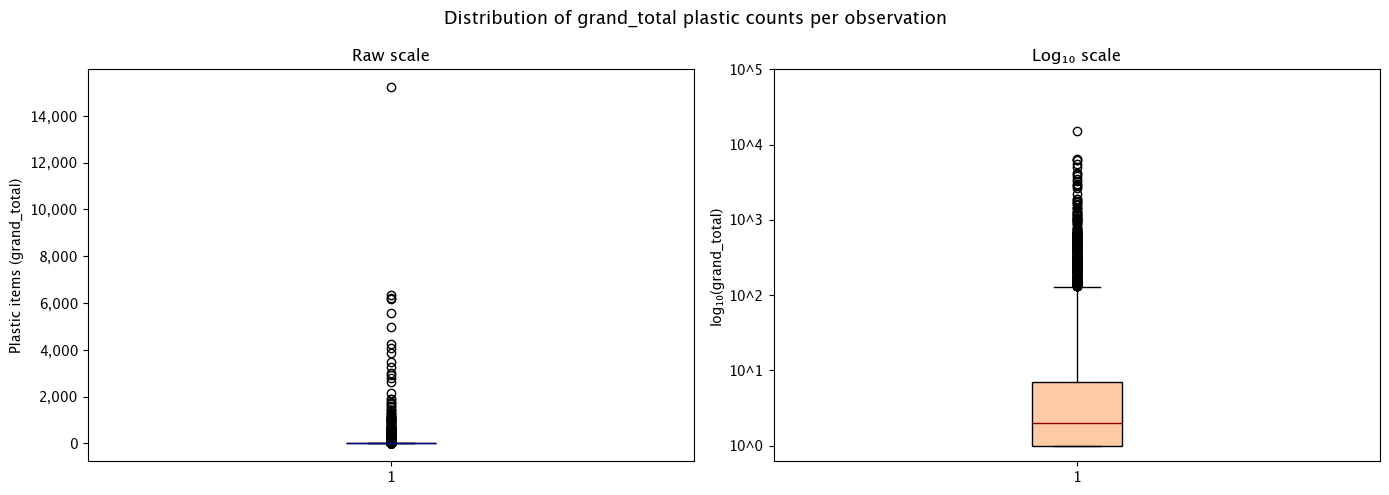

In [10]:
#outlier visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of grand_total plastic counts per observation', fontsize=13)

# Left: raw scale
axes[0].boxplot(df['grand_total'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#a8d8ea'), medianprops=dict(color='navy'))
axes[0].set_title('Raw scale')
axes[0].set_ylabel('Plastic items (grand_total)')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: log scale (better shows spread)
log_vals = np.log10(df['grand_total'].clip(lower=0.1))
axes[1].boxplot(log_vals, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#ffcba4'), medianprops=dict(color='darkred'))
axes[1].set_title('Log₁₀ scale')
axes[1].set_ylabel('log₁₀(grand_total)')
axes[1].set_yticks(range(0, 6))
axes[1].set_yticklabels([f'10^{i}' for i in range(0, 6)])

plt.tight_layout()
plt.show()

<p style="text-align: justify;">Figure above shows the distribution of plastic item counts per company-country-year observation on both raw and log₁₀ scales. On the raw scale (left), the interquartile box is indistinguishable from zero, illustrating just how compressed the bulk of the data is relative to the extreme high-count observations. Switching to a log₁₀ scale (right) reveals the underlying structure more clearly: the median observation contains approximately 2 plastic items, and the middle 50% of observations fall between 1 and roughly 8 items. The upper whisker extends to around 100 items, beyond which a dense cluster of outliers spans several orders of magnitude up to a maximum of 15,221 items — a single company (La Doo) recorded during a large-scale audit event in Nigeria. These high-count outliers are not removed, as they represent legitimate audit events with high volunteer participation rather than data entry errors. However, their presence means any aggregate ranking of companies is heavily influenced by a small number of large events, which is important context for interpreting the Local Giants analysis.</p>

Visualization 1 Over all top 10 companies in Asia 


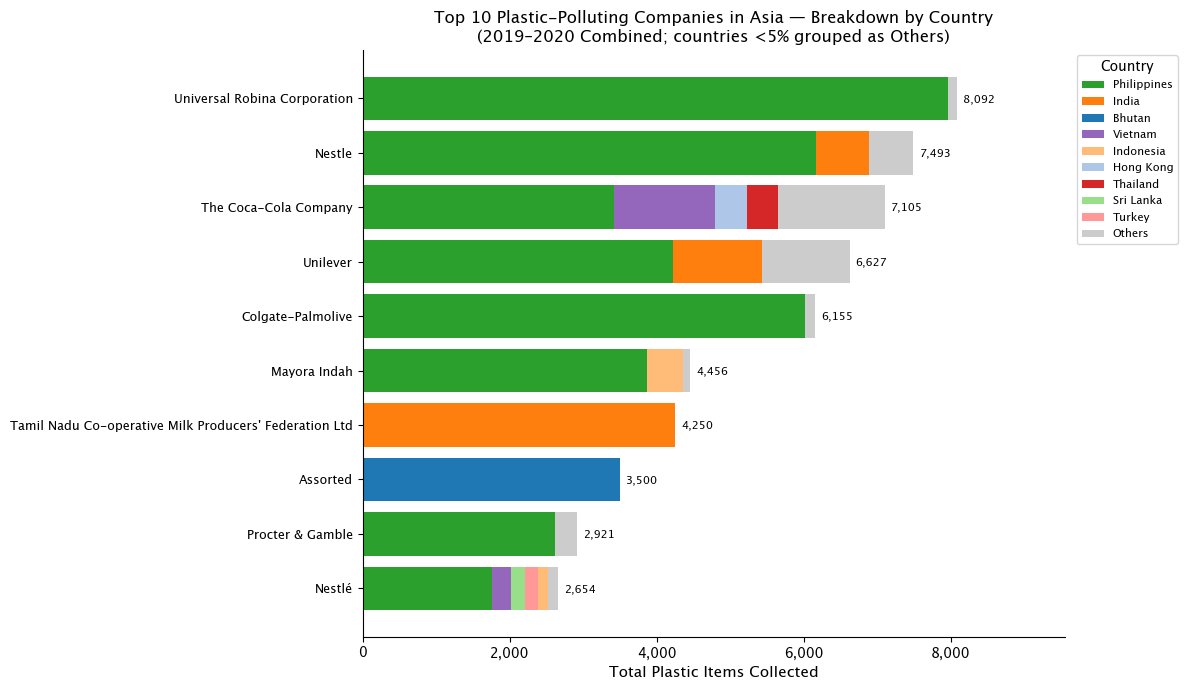

In [11]:
# Visualization 1: Top 10 companies in Asia — stacked by country (countries <5% → "Others")
# Within each bar, the biggest country segment is always drawn first (leftmost = bottom)

asia_df = df[df['continent'] == 'Asia']

# Top 10 companies in Asia by total plastic
asia_top10_names = (
    asia_df.groupby('parent_company')['grand_total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Country breakdown per company
breakdown = (
    asia_df[asia_df['parent_company'].isin(asia_top10_names)]
    .groupby(['parent_company', 'country'])['grand_total']
    .sum()
    .reset_index()
)

# Collapse countries <5% per company into "Others"
company_totals = breakdown.groupby('parent_company')['grand_total'].sum()
breakdown['pct'] = breakdown['grand_total'] / breakdown['parent_company'].map(company_totals)
breakdown['country_label'] = breakdown.apply(
    lambda r: r['country'] if r['pct'] >= 0.05 else 'Others', axis=1
)
breakdown = (
    breakdown.groupby(['parent_company', 'country_label'])['grand_total']
    .sum()
    .reset_index()
)

# Order companies by total (ascending so largest is at top of horizontal chart)
company_order = company_totals.sort_values(ascending=True).index.tolist()

# Consistent color map across all country labels (Others always grey)
all_countries = sorted(c for c in breakdown['country_label'].unique() if c != 'Others')
palette = sns.color_palette('tab20', n_colors=len(all_countries))
color_map = dict(zip(all_countries, palette))
color_map['Others'] = '#cccccc'

# Build legend entries in the order countries first appear (by total desc)
country_global_total = (
    breakdown[breakdown['country_label'] != 'Others']
    .groupby('country_label')['grand_total'].sum()
    .sort_values(ascending=False)
)
legend_order = list(country_global_total.index) + (['Others'] if 'Others' in color_map else [])

fig, ax = plt.subplots(figsize=(12, 7))

for y_pos, company in enumerate(company_order):
    comp_data = breakdown[breakdown['parent_company'] == company].copy()
    # Sort: biggest country first (left), Others always last (right)
    non_others = comp_data[comp_data['country_label'] != 'Others'].sort_values('grand_total', ascending=False)
    others     = comp_data[comp_data['country_label'] == 'Others']
    comp_data  = pd.concat([non_others, others])

    left = 0
    for _, row in comp_data.iterrows():
        ax.barh(y_pos, row['grand_total'], left=left,
                color=color_map[row['country_label']],
                label=row['country_label'])
        left += row['grand_total']

    # Total label at end of bar
    ax.text(left + 80, y_pos, f'{int(left):,}', va='center', fontsize=8)

ax.set_yticks(range(len(company_order)))
ax.set_yticklabels(company_order, fontsize=9)
ax.set_xlabel('Total Plastic Items Collected', fontsize=11)
ax.set_title(
    'Top 10 Plastic-Polluting Companies in Asia — Breakdown by Country\n'
    '(2019–2020 Combined; countries <5% grouped as Others)',
    fontsize=12, fontweight='bold'
)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, company_totals.max() * 1.18)

# Deduplicated legend in consistent order
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ordered_handles = [seen[l] for l in legend_order if l in seen]
ordered_labels  = [l for l in legend_order if l in seen]
ax.legend(ordered_handles, ordered_labels, title='Country',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()


Visualization 2

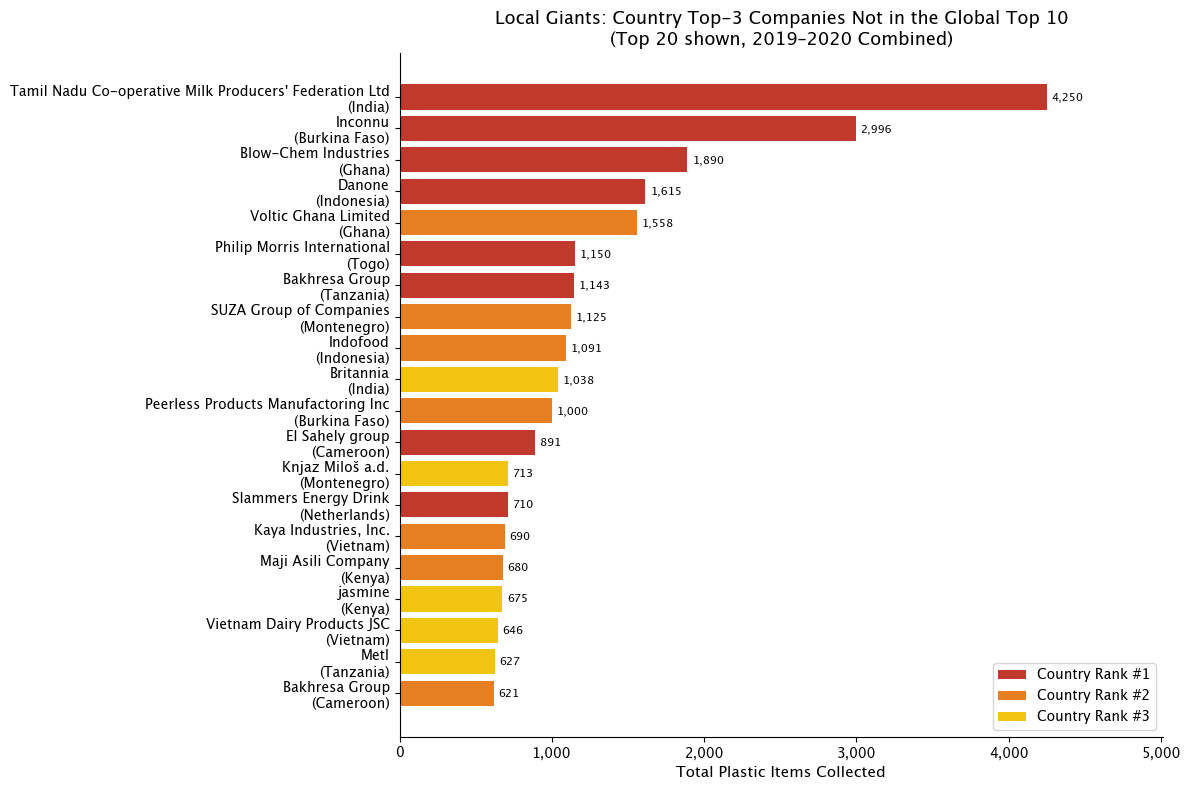

In [12]:
# Visualization 2: Local Giants — Top-3 per country but absent from the global Top 10

from matplotlib.patches import Patch

# Global Top 10 companies (all countries, all years)
global_top10 = set(
    df.groupby('parent_company')['grand_total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Aggregate per country × company, then rank within each country
country_company = (
    df.groupby(['country', 'continent', 'parent_company'])['grand_total']
    .sum()
    .reset_index()
)
country_company['country_rank'] = (
    country_company.groupby('country')['grand_total']
    .rank(ascending=False, method='first')
)

# Local Giants: country rank ≤ 3, not in global Top 10
local_giants = (
    country_company[
        (country_company['country_rank'] <= 3) &
        (~country_company['parent_company'].isin(global_top10))
    ]
    .sort_values('grand_total', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

labels = local_giants['parent_company'] + '\n(' + local_giants['country'] + ')'

rank_colors = {1: '#c0392b', 2: '#e67e22', 3: '#f1c40f'}
bar_colors  = local_giants['country_rank'].map(rank_colors)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(labels[::-1].values, local_giants['grand_total'][::-1].values, color=bar_colors[::-1].values)

for bar, val in zip(bars, local_giants['grand_total'][::-1].values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{int(val):,}', va='center', fontsize=8)

legend_elements = [Patch(facecolor=c, label=f'Country Rank #{r}') for r, c in rank_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_xlabel('Total Plastic Items Collected', fontsize=11)
ax.set_title(
    'Local Giants: Country Top-3 Companies Not in the Global Top 10\n(Top 20 shown, 2019–2020 Combined)',
    fontsize=13, fontweight='bold'
)
ax.set_xlim(0, local_giants['grand_total'].max() * 1.18)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()


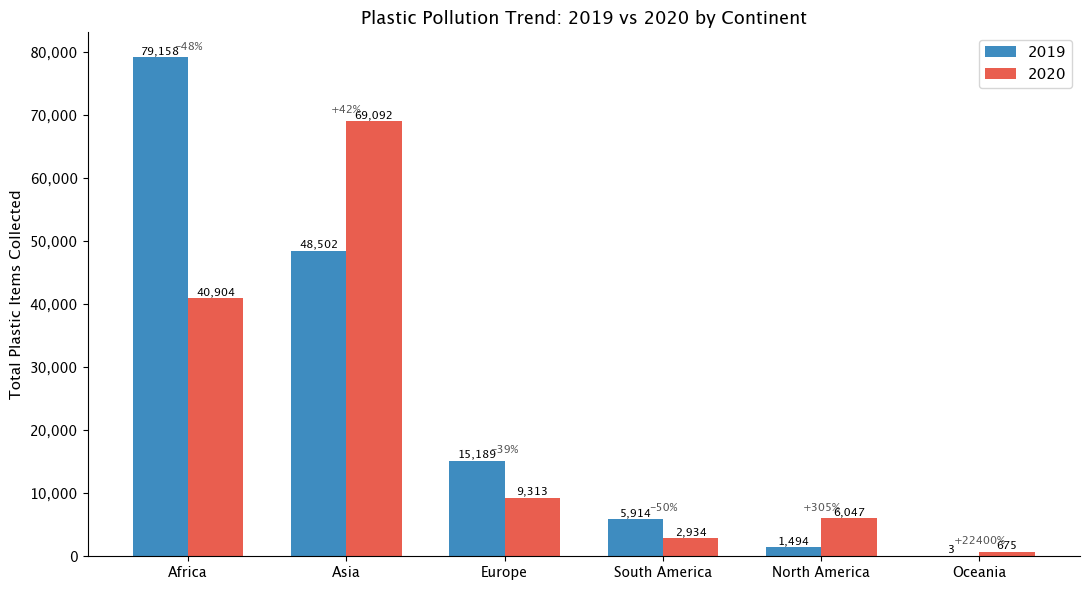

In [13]:
# Visualization 3: Plastic pollution trend — 2019 vs 2020 by continent

trend = (
    df.groupby(['continent', 'year'])['grand_total']
    .sum()
    .reset_index()
    .pivot(index='continent', columns='year', values='grand_total')
    .fillna(0)
    .sort_values(2019, ascending=False)
)

x = np.arange(len(trend))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_2019 = ax.bar(x - width / 2, trend[2019], width, label='2019', color='#2980b9', alpha=0.9)
bars_2020 = ax.bar(x + width / 2, trend[2020], width, label='2020', color='#e74c3c', alpha=0.9)

for bar in bars_2019:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 150,
                f'{int(h):,}', ha='center', va='bottom', fontsize=8)
for bar in bars_2020:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 150,
                f'{int(h):,}', ha='center', va='bottom', fontsize=8)

# Annotate % change
for i, continent in enumerate(trend.index):
    v2019, v2020 = trend.loc[continent, 2019], trend.loc[continent, 2020]
    if v2019 > 0:
        pct_change = (v2020 - v2019) / v2019 * 100
        sign = '+' if pct_change >= 0 else ''
        ax.text(i, max(v2019, v2020) + 1200,
                f'{sign}{pct_change:.0f}%', ha='center', fontsize=8, color='#555555')

ax.set_xticks(x)
ax.set_xticklabels(trend.index, fontsize=10)
ax.set_ylabel('Total Plastic Items Collected', fontsize=11)
ax.set_title('Plastic Pollution Trend: 2019 vs 2020 by Continent', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()


Visualization 3

Discussions

Teamwork

References

1. Break Free From Plastic. (2021). *Brand Audit Data 2019–2020*. Retrieved from [https://github.com/rfordatascience/tidytuesday/tree/master/data/2021/2021-01-26](https://github.com/rfordatascience/tidytuesday/tree/master/data/2021/2021-01-26)